# Graphics updates: tasks #5, #6, #8, #9

Demo notebook for four items from `team/symbulate-graphics-tasklist.md`, run
against the `feature/bins-marginal-fixes` branch. Each section just shows the
behavior -- see `DECISIONS.md` for the full rationale behind each choice.

In [1]:
from symbulate import *
import numpy as np

## #5 -- Outlier/skew-aware histogram binning

`RV(F(5,4)).sim(10000)` is heavily right-skewed: 99% of the mass sits below
~16, but the max can be 100+ from rare draws. The old fixed 30-bin-over-raw-
range histogram crushed almost the whole shape into 1-2 bars. `make_hist` now
adapts the *number* of bins to the data (a Freedman-Diaconis bin width
computed over the full range) -- still plain equal-width bins over the true
min-to-max, just a lot more of them, so the bulk of the shape actually
resolves.

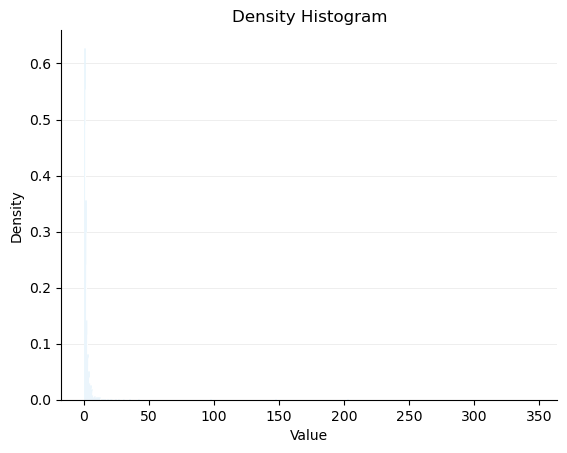

In [2]:
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(suggest=False)

That's around 1600-1800 bins here (varies by sample) -- the true full range
is still shown, nothing is clipped or set aside in a separate bin, it's just
enough bins that the bulk (below ~16) is no longer squeezed into 1-2 bars.
The tradeoff, accepted deliberately: since these are equal-width bins over
the *whole* range, a good chunk of the chart's width is still a near-empty
stretch out toward the rare large draws -- more bins can't change that, only
zooming the range could, and we specifically didn't want to zoom/clip.

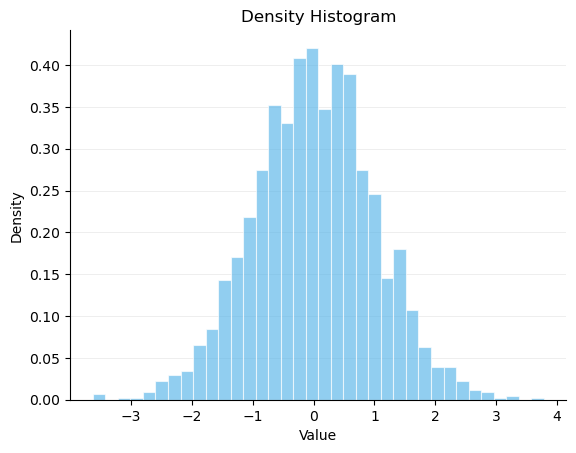

In [3]:
# Well-behaved (symmetric) data doesn't need many more bins than the flat
# default -- the bin count adapts to the data, it doesn't just always grow.
np.random.seed(0)
RV(Normal(0, 1)).sim(2000).plot(suggest=False)

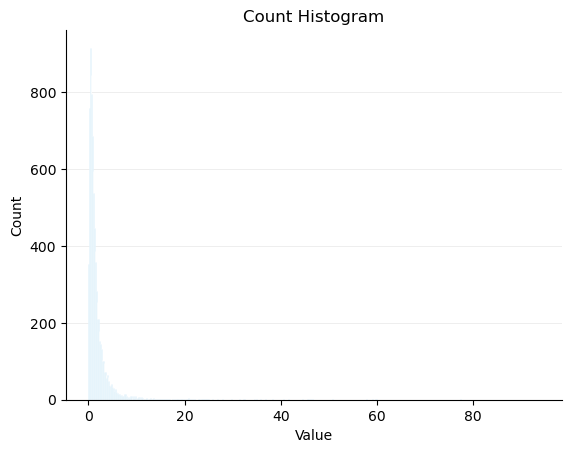

In [4]:
# normalize=False: raw counts, same adaptive binning.
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(normalize=False, suggest=False)

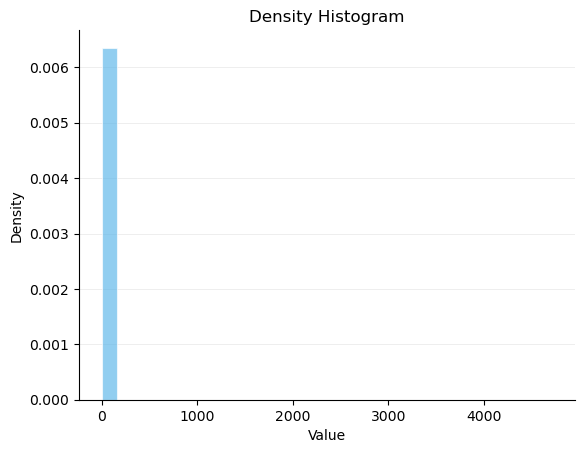

In [5]:
# An explicit bins= always wins outright -- exactly that many equal-width
# bins over the full range, not the (much larger) adaptive count. Existing
# notebook code that already sets bins= keeps working exactly as before.
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(bins=30, suggest=False)

## #6 -- Keeping the discreteness thresholds independent of the histogram's bin count

`B_1D`/`K_2D` (the discrete-vs-continuous crowding budget) were anchored to
`HIST_DEFAULT_BINS = 30` as a *rationale*, not a literal code dependency. Now
that `make_hist`'s own bin count is data-dependent (8-2000), that anchor
needed to be checked explicitly, not assumed.

In [6]:
from symbulate.plot import (
    B_1D, K_2D, HIST_DEFAULT_BINS, HIST2D_DEFAULT_BINS, TILE_DEFAULT_BINS,
    HIST_MIN_AUTO_BINS, HIST_MAX_AUTO_BINS,
)

print("B_1D  (1D discreteness budget):              ", B_1D)
print("K_2D  (2D discreteness budget):               ", K_2D)
print("HIST_DEFAULT_BINS   (make_hist's degenerate-\n"
      "  data fallback only, no longer 'the' bin count):", HIST_DEFAULT_BINS)
print("HIST2D_DEFAULT_BINS (make_hist2d -- unaffected):", HIST2D_DEFAULT_BINS)
print("TILE_DEFAULT_BINS   (make_tile -- unaffected): ", TILE_DEFAULT_BINS)
print("HIST_MIN_AUTO_BINS..HIST_MAX_AUTO_BINS",
      "(make_hist's new dynamic range):", HIST_MIN_AUTO_BINS, "-", HIST_MAX_AUTO_BINS)

B_1D  (1D discreteness budget):               30
K_2D  (2D discreteness budget):                30
HIST_DEFAULT_BINS   (make_hist's degenerate-
  data fallback only, no longer 'the' bin count): 30
HIST2D_DEFAULT_BINS (make_hist2d -- unaffected): 30
TILE_DEFAULT_BINS   (make_tile -- unaffected):  30
HIST_MIN_AUTO_BINS..HIST_MAX_AUTO_BINS (make_hist's new dynamic range): 8 - 2000


Only `make_hist` (the 1D histogram) got the dynamic bin count. The 2D mesh
helpers (`make_hist2d`, `make_tile`) still use the flat 30-bin scheme,
untouched -- same skewed distribution, shown three ways:

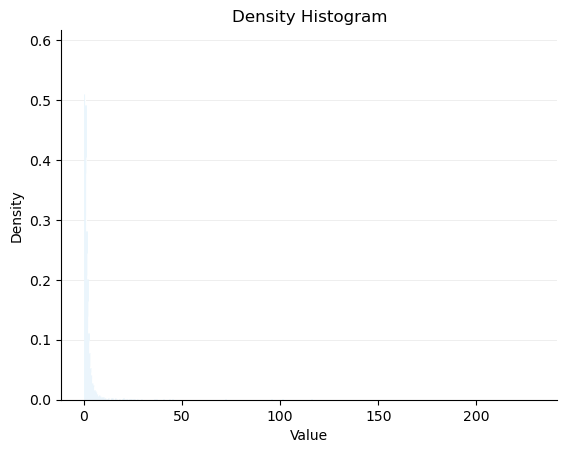

In [7]:
# 1D: dynamic bin count kicks in for skewed data (see #5 above) -- the
# bulk resolves over the full range, no clipping.
np.random.seed(0)
RV(F(5, 4)).sim(10000).plot(type="hist", suggest=False)

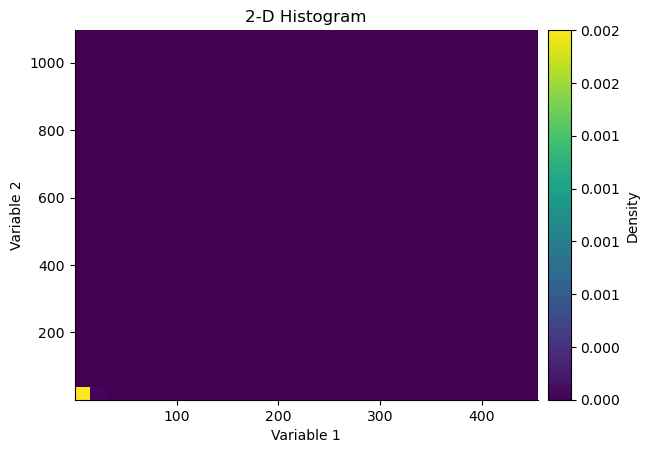

In [8]:
# 2D histogram: still the flat 30-bin scheme, completely untouched by #5 --
# the same skewed variable crossed with itself still crushes into a corner.
np.random.seed(0)
X, Y = RV(F(5, 4) ** 2)
(X & Y).sim(10000).plot(type="hist2d", suggest=False)

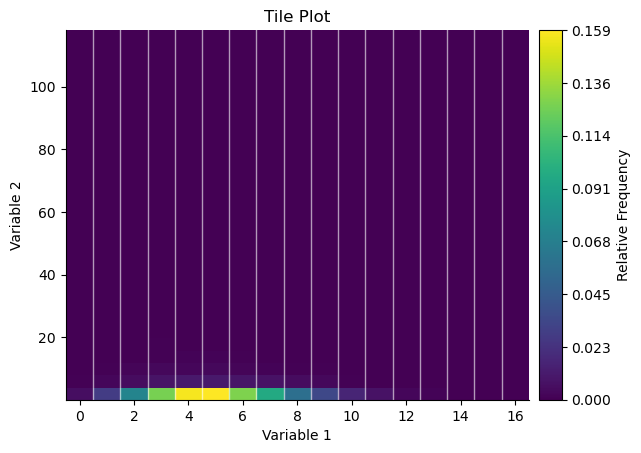

In [9]:
# Tile's continuous axis: same flat 30-bin scheme, also untouched -- a
# skewed continuous axis crossed with a discrete one still crushes the
# same way it did before #5 (a separate, not-yet-tackled problem, but
# confirmed *unaffected* by #5's change rather than silently inheriting it).
np.random.seed(0)
X, Y = RV(Poisson(lam=5) * F(5, 4))
(X & Y).sim(10000).plot(type="tile", suggest=False)

The other half of #6: did the *discrete-vs-continuous split itself*
(`classify_values`, gated by `B_1D`/`K_2D`) quietly start depending on
`make_hist`'s new bin count? The sharpest test is a distribution sitting
right at the `B_1D = 30` boundary -- if the classifier had somehow picked up
a dependency on the histogram's (now dynamic) bin count, this is where it
would show up first.

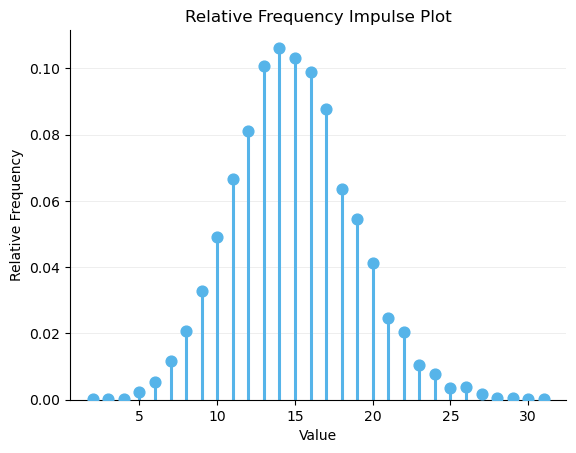

In [10]:
# Poisson(15) realizes ~30 distinct values at n=10000 -- right at the B_1D
# edge. It still reads as discrete (an impulse plot, not a histogram),
# exactly as before -- classify_values never looked at make_hist's bin
# count in the first place, dynamic or not.
np.random.seed(0)
RV(Poisson(15)).sim(10000).plot(suggest=False)

## #8 -- Marginal panel rebuild (real helpers + coordinate alignment)

Marginal panels (`marginal=True`) used to run through legacy, pre-redesign
code and could visually misalign with the main panel. Confirmed case:
`DiscreteUniform(50,60)` starts at 50, but tile's discrete axis used to plot
at compressed index positions (0-10) while the marginal plotted at real
values (50-60) -- two different scales stacked in one figure.

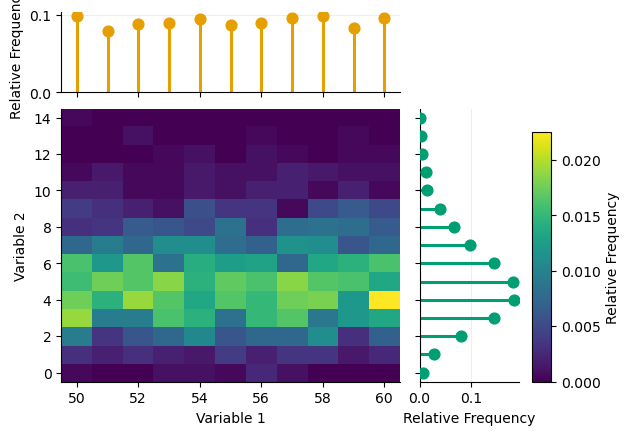

In [11]:
np.random.seed(0)
X, Y = RV(DiscreteUniform(a=50, b=60) * Poisson(lam=5))
(X & Y).sim(2000).plot(type="tile", marginal=True, suggest=False)

Main panel and marginals now share exactly the same scale on both axes.

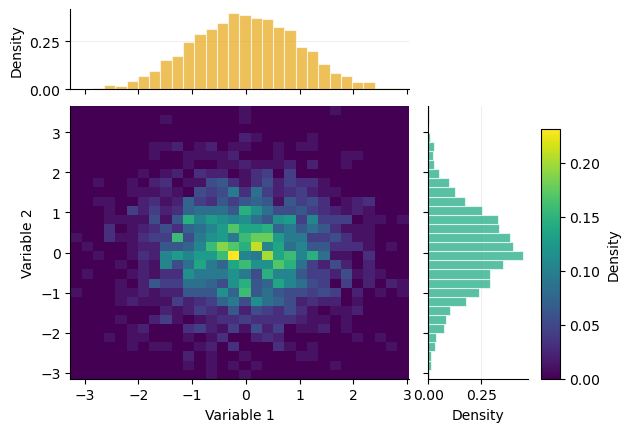

In [12]:
# hist2d + marginal: continuous x continuous, large n.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(2000).plot(type="hist2d", marginal=True, suggest=False)

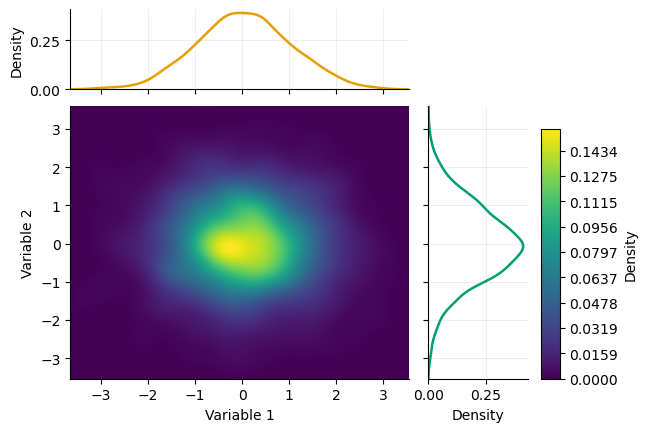

In [13]:
# density2d + marginal: when the main panel is a density surface, both
# marginals draw density curves too -- not impulse/hist -- matching the
# main panel's own representation.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(2000).plot(type="density2d", marginal=True, suggest=False)

Marginal type is now routed through `classify_values` per axis, just like a
standalone 1D variable would be -- not hardcoded to impulse-or-hist regardless
of sample size.

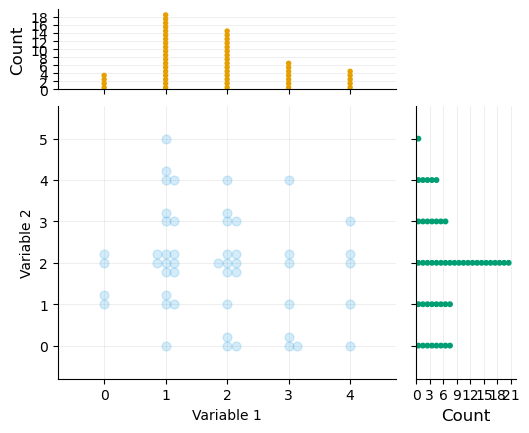

In [14]:
# Small-n discrete x discrete: dot-plot marginals, not impulse.
np.random.seed(0)
X, Y = RV(Binomial(5, 0.4) ** 2)
(X & Y).sim(50).plot(type="scatter", marginal=True, suggest=False)

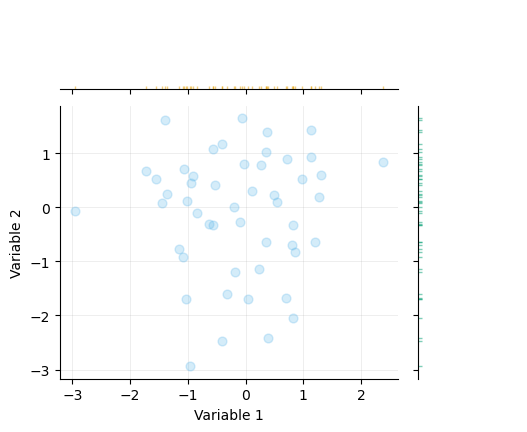

In [15]:
# Small-n continuous x continuous: rug marginals.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(50).plot(type="scatter", marginal=True, suggest=False)

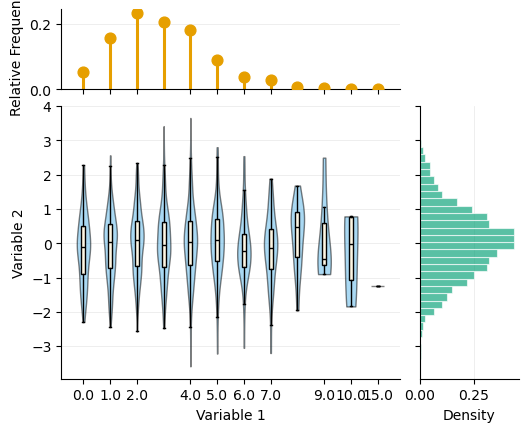

In [16]:
# Mixed data (one discrete axis, one continuous) works too -- here with violin.
np.random.seed(0)
X, Y = RV(Poisson(lam=3) * Normal(0, 1))
(X & Y).sim(2000).plot(type="violin", marginal=True, suggest=False)

`mosaic` is the one deliberate exception: it already shows x's marginal via
column width and y's marginal via its own optional side column, so a second,
generic marginal mechanism would just be redundant. `marginal=True` with
`type="mosaic"` raises a friendly error pointing at that existing feature
instead of drawing a duplicate.

In [17]:
try:
    X, Y = RV(Binomial(5, 0.4) ** 2)
    (X & Y).sim(500).plot(type="mosaic", marginal=True)
except ValueError as e:
    print(e)

marginal=True isn't supported with type='mosaic' -- a mosaic plot already shows x's marginal distribution through its column widths and y's marginal distribution through its own marginal column. Use type='mosaic', marginal_column=True (the default) instead of marginal=True.


## #9 -- `marginal=True` instead of `type=[..., "marginal"]`

`marginal` used to be a string smuggled into the `type=` list, which was
inconsistent with every other modifier (`bins=`, `jitter=`) already being a
real keyword. It's now its own `marginal=True/False` argument.

In [18]:
# The old spelling is no longer valid -- it raises, and points at the fix.
try:
    X, Y = RV(Normal(0, 1) ** 2)
    (X & Y).sim(500).plot(type=["hist", "marginal"])
except ValueError as e:
    print(e)

'marginal' is no longer a type= value -- it's now its own keyword argument. Use marginal=True instead, e.g. .plot(type='hist', marginal=True).


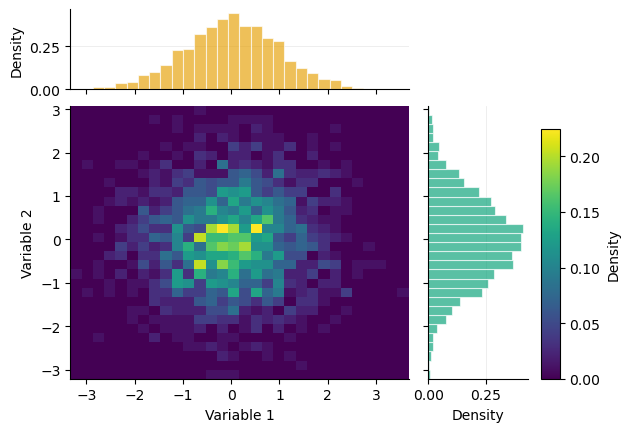

In [19]:
# The new spelling: marginal is its own argument, combined with type= as usual.
np.random.seed(0)
X, Y = RV(Normal(0, 1) ** 2)
(X & Y).sim(2000).plot(type="hist", marginal=True, suggest=False)